# 26b visualize natural-unit $A_{\tau,eff}$ near $m_{\rm res}$

`26-natural_unit_aeff_mres.py` の CSV を読み、visibility-weighted な physical $A_\tau$ が $m_{\rm res}$ 近傍でどう振る舞うかを見る。


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path('/home/yminami/workdir/CosmicBirefringence/PatchyReionization')
CSV = ROOT / 'results' / '26-natural-unit-aeff-mres' / 'natural_unit_aeff_mres_scan.csv'
df = pd.read_csv(CSV).sort_values(["g_GeV_inv", "mass_over_mres"]).reset_index(drop=True)
display(df.head())
df.tail()


,mass_eV,m_res_fid_eV,mass_over_mres,g_GeV_inv,phi_unit,dphi_dx_unit,rho_unit_GeV4,rho_dm_GeV4,phi_amp_max_nat_GeV,A_unit_old_mixed,A_eff_old_mixed,Aeff_over_Aunit,A_unit_nat,A_eff_nat,A_tau_unit_physical,A_tau_eff_physical,lambda_osc_Mpc,N_osc_patchy
0,5.119815e-30,1.023963e-29,0.500000,1.400000e-12,0.004754,1.027937,5.240693e-82,7.167749e-62,1.169491e+10,3.896985e+09,1.879729e+08,0.048235,12.998942,0.627010,0.106415,0.005133,68.278000,13.530132
1,5.361952e-30,1.023963e-29,0.523647,1.400000e-12,0.004402,-1.083364,5.316658e-82,7.167749e-62,1.161106e+10,-4.107113e+09,-1.467189e+08,0.035723,-13.699855,-0.489402,-0.111349,-0.003978,65.194675,14.170028
2,5.615541e-30,1.023963e-29,0.548412,1.400000e-12,-0.004990,-0.790803,5.274129e-82,7.167749e-62,1.165778e+10,-2.997994e+09,4.046461e+08,-0.134972,-10.000231,1.349754,-0.081606,0.011015,62.250588,14.840187
3,5.881123e-30,1.023963e-29,0.574349,1.400000e-12,0.000710,1.555827,5.306902e-82,7.167749e-62,1.162173e+10,5.898258e+09,8.535322e+08,0.144709,19.674470,2.847077,0.160056,0.023162,59.439451,15.542041
4,6.159265e-30,1.023963e-29,0.601513,1.400000e-12,0.001950,-1.464644,5.347206e-82,7.167749e-62,1.157785e+10,-5.552577e+09,8.068148e+07,-0.014530,-18.521402,0.269124,-0.150107,0.002181,56.755261,16.277088


,mass_eV,m_res_fid_eV,mass_over_mres,g_GeV_inv,phi_unit,dphi_dx_unit,rho_unit_GeV4,rho_dm_GeV4,phi_amp_max_nat_GeV,A_unit_old_mixed,A_eff_old_mixed,Aeff_over_Aunit,A_unit_nat,A_eff_nat,A_tau_unit_physical,A_tau_eff_physical,lambda_osc_Mpc,N_osc_patchy
57,1.702314e-29,1.023963e-29,1.662476,4.000000e-12,-0.001327,1.226341,5.793321e-82,7.167749e-62,1.112314e+10,4.649149e+09,-9.864945e+07,-0.021219,15.507892,-0.329059,0.344993,-0.007320,20.535036,44.987035
58,1.782823e-29,1.023963e-29,1.741101,4.000000e-12,-0.000082,1.640162,5.811644e-82,7.167749e-62,1.110560e+10,6.217979e+09,5.500401e+08,0.088460,20.740944,1.834736,0.460681,0.040752,19.607707,47.114658
59,1.867140e-29,1.023963e-29,1.823445,4.000000e-12,0.001754,-0.473490,5.844868e-82,7.167749e-62,1.107399e+10,-1.795037e+09,1.244442e+08,-0.069327,-5.987598,0.415101,-0.132613,0.009194,18.722254,49.342904
60,1.955445e-29,1.023963e-29,1.909683,4.000000e-12,-0.001657,0.539088,5.874813e-82,7.167749e-62,1.104573e+10,2.043724e+09,-2.066157e+08,-0.101098,6.817131,-0.689196,0.150600,-0.015225,17.876787,51.676533
61,2.047926e-29,1.023963e-29,2.000000,4.000000e-12,-0.000235,-1.637342,5.896909e-82,7.167749e-62,1.102501e+10,-6.207286e+09,-6.258415e+08,0.100824,-20.705277,-2.087583,-0.456552,-0.046031,17.069500,54.120530


In [2]:
summary = []
for g, sub in df.groupby("g_GeV_inv"):
    peak_idx = sub["A_tau_eff_physical"].abs().idxmax()
    summary.append(df.loc[peak_idx, ["g_GeV_inv", "mass_eV", "mass_over_mres", "A_tau_unit_physical", "A_tau_eff_physical", "Aeff_over_Aunit"]])
summary = pd.DataFrame(summary)
display(summary)


,g_GeV_inv,mass_eV,mass_over_mres,A_tau_unit_physical,A_tau_eff_physical,Aeff_over_Aunit
3,1.400000e-12,5.881123e-30,0.574349,0.160056,0.023162,0.144709
34,4.000000e-12,5.881123e-30,0.574349,0.457303,0.066176,0.144709


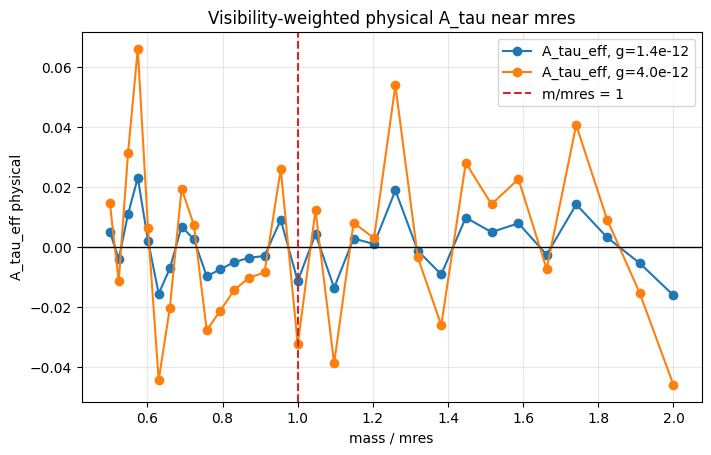

In [3]:
fig, ax = plt.subplots(figsize=(8, 4.8))
for g, sub in df.groupby("g_GeV_inv"):
    ax.plot(sub["mass_over_mres"], sub["A_tau_eff_physical"], marker="o", label=f"A_tau_eff, g={g:.1e}")
ax.axhline(0.0, color="black", lw=1)
ax.axvline(1.0, color="C3", lw=1.5, ls="--", label="m/mres = 1")
ax.set_xlabel("mass / mres")
ax.set_ylabel("A_tau_eff physical")
ax.set_title("Visibility-weighted physical A_tau near mres")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()


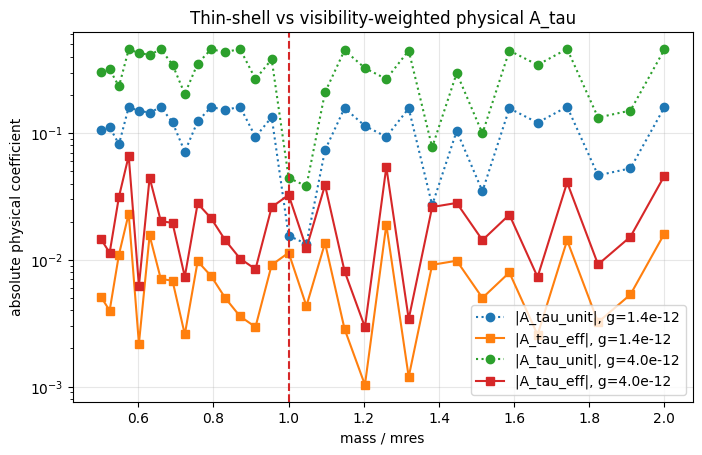

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.8))
for g, sub in df.groupby("g_GeV_inv"):
    ax.plot(sub["mass_over_mres"], sub["A_tau_unit_physical"].abs(), marker="o", ls=":", label=f"|A_tau_unit|, g={g:.1e}")
    ax.plot(sub["mass_over_mres"], sub["A_tau_eff_physical"].abs(), marker="s", label=f"|A_tau_eff|, g={g:.1e}")
ax.axvline(1.0, color="C3", lw=1.5, ls="--")
ax.set_yscale("log")
ax.set_xlabel("mass / mres")
ax.set_ylabel("absolute physical coefficient")
ax.set_title("Thin-shell vs visibility-weighted physical A_tau")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()
